In [1]:
# import libraries (you may add additional imports but you may not have to)
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

In [2]:
# get data files
!wget https://cdn.freecodecamp.org/project-data/books/book-crossings.zip

!unzip book-crossings.zip

books_filename = 'BX-Books.csv'
ratings_filename = 'BX-Book-Ratings.csv'

--2025-05-02 09:49:13--  https://cdn.freecodecamp.org/project-data/books/book-crossings.zip
Resolving cdn.freecodecamp.org (cdn.freecodecamp.org)... 172.67.70.149, 104.26.3.33, 104.26.2.33, ...
Connecting to cdn.freecodecamp.org (cdn.freecodecamp.org)|172.67.70.149|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26085508 (25M) [application/zip]
Saving to: ‘book-crossings.zip’

book-crossings.zip  100%[===================>]  24.88M  --.-KB/s    in 0.1s    

2025-05-02 09:49:13 (174 MB/s) - ‘book-crossings.zip’ saved [26085508/26085508]

Archive:  book-crossings.zip
  inflating: BX-Book-Ratings.csv     
  inflating: BX-Books.csv            
  inflating: BX-Users.csv            


In [72]:
# import csv data into dataframes
df_books = pd.read_csv(
    books_filename,
    encoding = "ISO-8859-1",
    sep=";",
    header=0,
    names=['isbn', 'title', 'author'],
    usecols=['isbn', 'title', 'author'],
    dtype={'isbn': 'str', 'title': 'str', 'author': 'str'})

df_ratings = pd.read_csv(
    ratings_filename,
    encoding = "ISO-8859-1",
    sep=";",
    header=0,
    names=['user', 'isbn', 'rating'],
    usecols=['user', 'isbn', 'rating'],
    dtype={'user': 'int32', 'isbn': 'str', 'rating': 'float32'})

In [90]:
dfb = df_ratings.groupby("isbn").count().reset_index()
good_books = dfb.loc[dfb["rating"] >= 100, "isbn"]
good_books = df_books[df_books["isbn"].isin(good_books)]

dfu = df_ratings.groupby("user").count().reset_index()
good_users = dfu.loc[dfu["rating"] >= 200, "user"]
df = df_ratings[
    df_ratings["user"].isin(good_users) &
    df_ratings["isbn"].isin(good_books["isbn"])
]


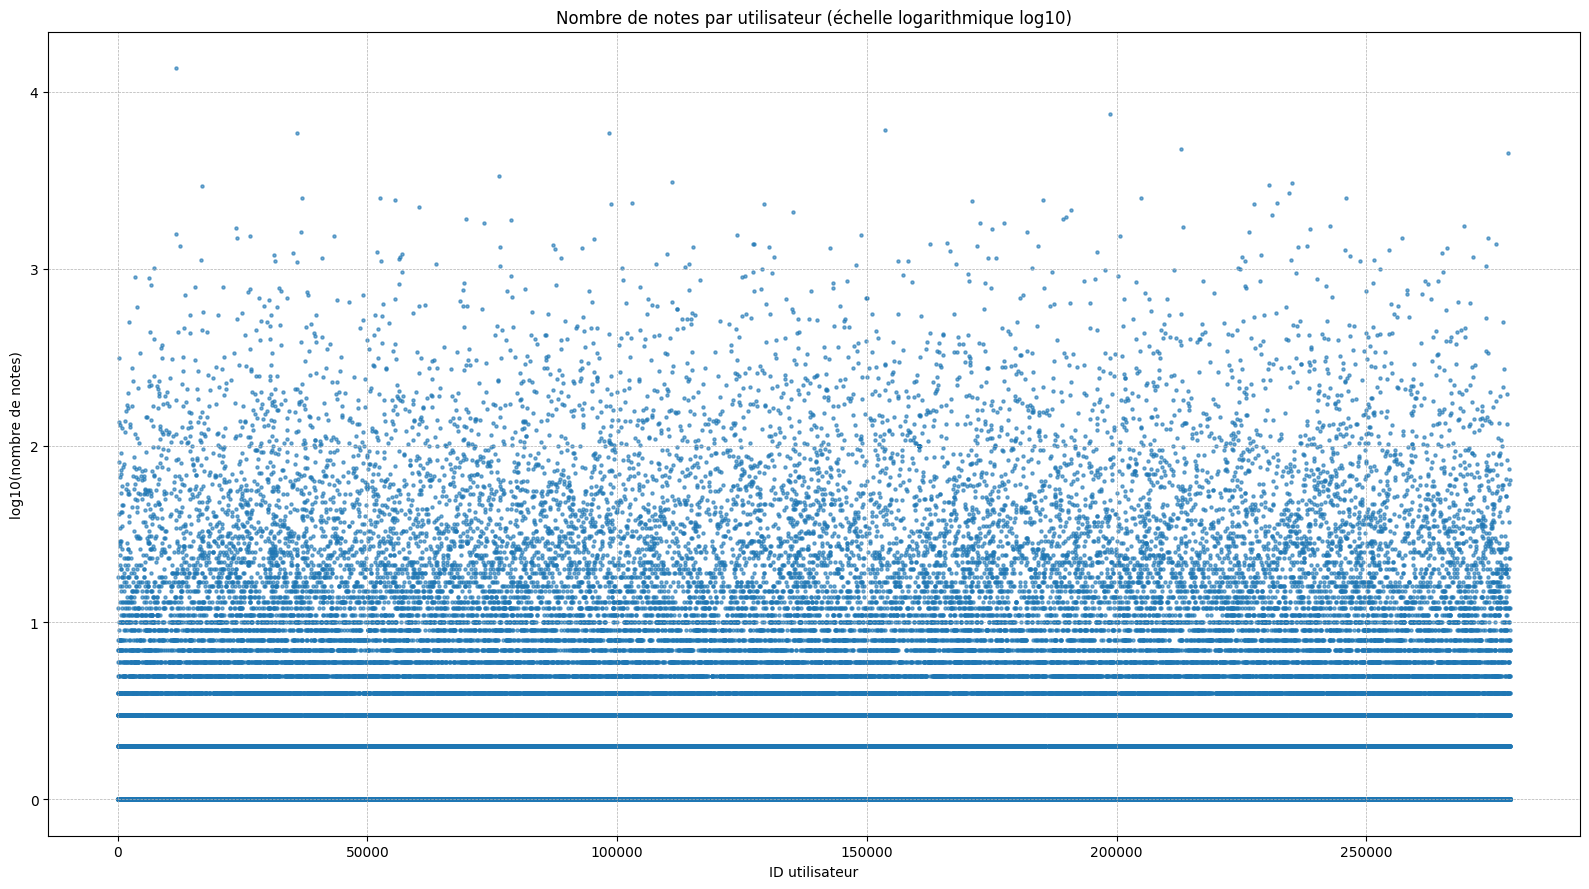

In [95]:
# Affichage des graphiques directement dans le notebook
%matplotlib inline

# Taille de la figure (largeur, hauteur)
plt.rcParams["figure.figsize"] = (16, 9)

# ------------------------------------------------------------------
# 1. Nombre de notes explicites (1–10) par utilisateur
# ------------------------------------------------------------------
df = (
    df_ratings                # DataFrame contenant toutes les notations
      .groupby("user")["rating"]   # regrouper par identifiant utilisateur
      .count()                     # compter le nombre de notes
      .reset_index()               # repasser en DataFrame classique
      .rename(columns={"rating": "nb_notes"})
)

# ------------------------------------------------------------------
# 2. Colonne log10 pour mieux visualiser la distribution
# ------------------------------------------------------------------
df["log10_nb_notes"] = np.log10(df["nb_notes"])

# ------------------------------------------------------------------
# 3. Nuage de points
# ------------------------------------------------------------------
df.plot.scatter(
    x="user",
    y="log10_nb_notes",
    s=5,            # taille des points
    alpha=0.6       # transparence légère
)

plt.title("Nombre de notes par utilisateur (échelle logarithmique log10)")
plt.xlabel("ID utilisateur")
plt.ylabel("log10(nombre de notes)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


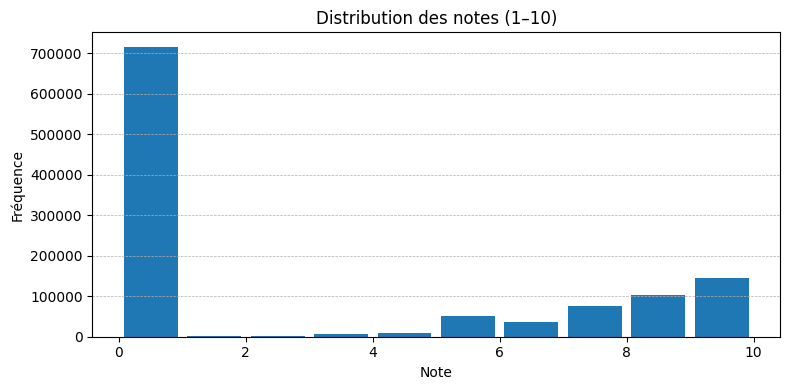

In [96]:
plt.figure(figsize=(8, 4))
plt.hist(df_ratings['rating'], bins=10, rwidth=0.85)
plt.title('Distribution des notes (1–10)')
plt.xlabel('Note')
plt.ylabel('Fréquence')
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [97]:
# 1) Livres avec >= 100 notes
dfb = df_ratings.groupby("isbn")["rating"].count().reset_index()
good_books_isbn = dfb.loc[dfb["rating"] >= 100, "isbn"]

good_books = df_books[df_books["isbn"].isin(good_books_isbn)]

# 2) Utilisateurs avec >= 200 notes
dfu = df_ratings.groupby("user")["rating"].count().reset_index()
good_users = dfu.loc[dfu["rating"] >= 200, "user"]

# 3) Sous‑échantillon final (notes peu “fiables” supprimées)
df = df_ratings[
    df_ratings["user"].isin(good_users) &
    df_ratings["isbn"].isin(good_books_isbn)
]

# pivot: lignes = livres (isbn) / colonnes = utilisateurs / valeurs = note
df_book_features = df.pivot(
    index='isbn',
    columns='user',
    values='rating'
).fillna(0)

mat_book_features = csr_matrix(df_book_features.values)

model = NearestNeighbors(metric='cosine')  # default algorithm='auto' ⇒ 'brute'
model.fit(mat_book_features)


NearestNeighbors(metric='cosine')

In [92]:
def get_recommends(title=""):
    # 1. Trouver l'ISBN correspondant au titre donné
    book_row = good_books[good_books["title"] == title]
    if book_row.empty:
        return f"Le livre « {title} » est absent de la base filtrée."

    isbn = book_row.iloc[0]["isbn"]

    # 2. Récupérer le vecteur-ligne du livre (dans la même forme 2‑D que scikit attend)
    vec = df_book_features.loc[[isbn]].values      # shape = (1, n_users)

    # 3. Chercher les 6 voisins (lui‑même + 5 autres)
    distances, indices = model.kneighbors(vec, n_neighbors=6)

    # 4. On ignore l'indice 0 (distance 0 ⇒ le livre lui‑même)
    distances, indices = distances[0][1:], indices[0][1:]

    # 5. Conversion indices → titres (et non ISBN) pour l'affichage
    titles = [
        df_books.loc[df_books["isbn"] == df_book_features.index[i], "title"].values[0]
        for i in indices
    ]

    # 6. Zipper titres + distances (float32 → float) et inverser l'ordre pour coller au test FCC
    recommended = [list(z) for z in zip(titles, distances.astype(float))][::-1]

    return [title, recommended]


In [98]:
books = get_recommends("Where the Heart Is (Oprah's Book Club (Paperback))")
print(books)

def test_book_recommendation():
  test_pass = True
  recommends = get_recommends("Where the Heart Is (Oprah's Book Club (Paperback))")
  if recommends[0] != "Where the Heart Is (Oprah's Book Club (Paperback))":
    test_pass = False
  recommended_books = ["I'll Be Seeing You", 'The Weight of Water', 'The Surgeon', 'I Know This Much Is True']
  recommended_books_dist = [0.8, 0.77, 0.77, 0.77]
  for i in range(2):
    if recommends[1][i][0] not in recommended_books:
      test_pass = False
    if abs(recommends[1][i][1] - recommended_books_dist[i]) >= 0.05:
      test_pass = False
  if test_pass:
    print("You passed the challenge! 🎉🎉🎉🎉🎉")
  else:
    print("You haven't passed yet. Keep trying!")

test_book_recommendation()

["Where the Heart Is (Oprah's Book Club (Paperback))", [["I'll Be Seeing You", np.float32(0.8016211)], ['The Weight of Water', np.float32(0.77085835)], ['The Surgeon', np.float32(0.7699411)], ['I Know This Much Is True', np.float32(0.7677075)], ['The Lovely Bones: A Novel', np.float32(0.7234864)]]]
You passed the challenge! 🎉🎉🎉🎉🎉
